In [1]:
%pip install faiss-cpu sentence-transformers

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

d:\nihal\datacamp\ML practice\ml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
corpus = [
    "AI can predict flood risks by analyzing satellite imagery and weather patterns.",
    "Machine learning models detect illegal deforestation in the Amazon rainforest.",
    "Neural networks classify water quality from sensor data in real time.",
    "AI-powered drones monitor coral reef health and detect bleaching events.",
    "Deep learning models predict air pollution levels in urban areas.",
    "Natural language processing helps scientists extract climate data from research papers.",
    "Reinforcement learning optimizes energy consumption in smart grids.",
    "Computer vision detects plastic waste in oceans using satellite images.",
    "AI forecasting models help farmers optimize irrigation to reduce water usage.",
    "Machine learning detects methane leaks from oil pipelines using infrared imagery.",
    "AI models analyze weather patterns to improve renewable energy predictions.",
    "Deep learning classifies species in biodiversity surveys from camera trap images.",
    "AI tracks glacier retreat and ice cap changes using satellite analysis.",
    "Predictive models warn communities about wildfire spread using wind and moisture data.",
    "AI systems monitor soil health and recommend sustainable farming practices.",
    "Machine learning helps optimize recycling by automatically sorting waste materials.",
    "Computer vision detects oil spills in oceans from satellite imagery.",
    "AI models predict drought conditions weeks in advance using climate models.",
    "Deep learning identifies endangered species in wildlife photographs automatically.",
    "AI monitors deforestation rates by comparing historical and current forest cover.",
]

print(f"Corpus size: {len(corpus)} documents")

Corpus size: 20 documents


In [4]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(corpus)

print("Shape:", embeddings.shape)
print("Each document is represented as", embeddings.shape[1], "numbers")

d:\nihal\datacamp\ML practice\ml_env\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Shape: (20, 384)
Each document is represented as 384 numbers


In [5]:
print(embeddings[0][:10])  # first 10 numbers of the first document

[-0.03253886 -0.0808081   0.10569593  0.01164715  0.0452216  -0.02144169
 -0.00278548 -0.02508361 -0.01180459  0.02605674]


In [6]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

print("Vectors in index:", index.ntotal)

Vectors in index: 20


In [7]:
query = "How does AI help with water pollution?"

query_embedding = model.encode([query])

k = 5
distances, indices = index.search(query_embedding, k)

print("Query:", query)
print("\nTop", k, "results:\n")
for i in range(k):
    print(f"Rank {i+1} | Distance: {distances[0][i]:.4f}")
    print(f"Doc: {corpus[indices[0][i]]}")
    print()

Query: How does AI help with water pollution?

Top 5 results:

Rank 1 | Distance: 0.8698
Doc: AI forecasting models help farmers optimize irrigation to reduce water usage.

Rank 2 | Distance: 0.9329
Doc: AI can predict flood risks by analyzing satellite imagery and weather patterns.

Rank 3 | Distance: 0.9550
Doc: Neural networks classify water quality from sensor data in real time.

Rank 4 | Distance: 1.0050
Doc: Deep learning models predict air pollution levels in urban areas.

Rank 5 | Distance: 1.0124
Doc: AI systems monitor soil health and recommend sustainable farming practices.



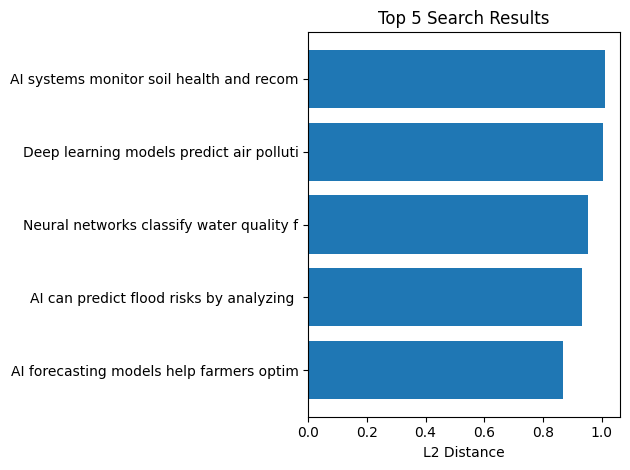

In [13]:
labels = [corpus[indices[0][i]][:40] for i in range(k)]
values = distances[0]

plt.barh(labels, values)
plt.xlabel("L2 Distance")
plt.title("Top 5 Search Results")
plt.tight_layout()
plt.show()

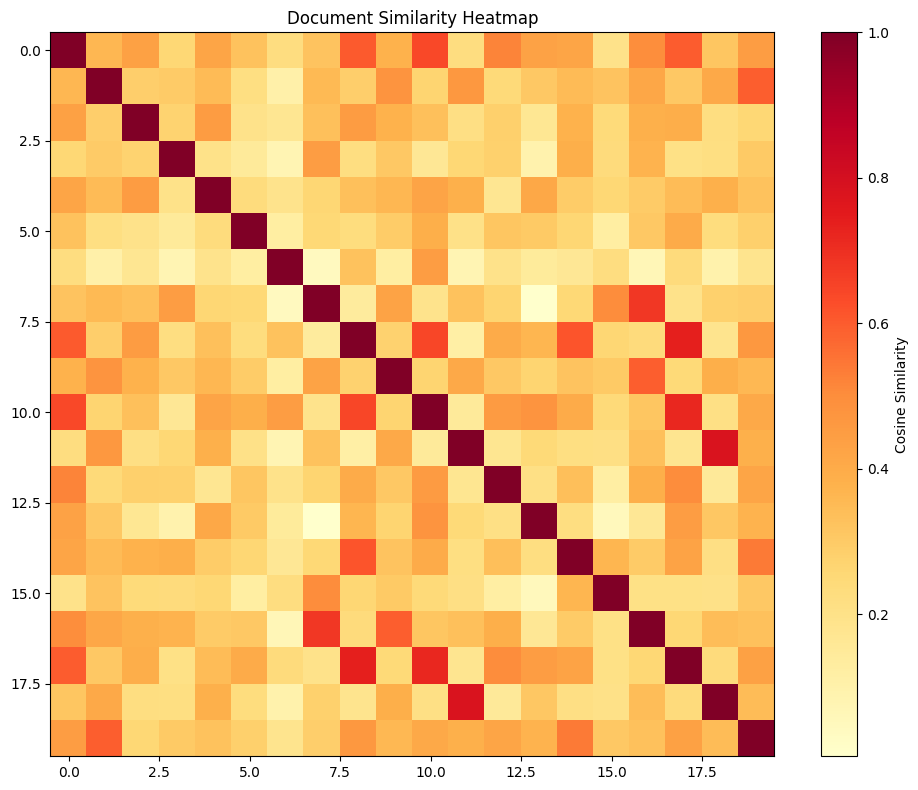

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

cos_sim = cosine_similarity(embeddings)

plt.figure(figsize=(10, 8))
plt.imshow(cos_sim, cmap="YlOrRd")
plt.colorbar(label="Cosine Similarity")
plt.title("Document Similarity Heatmap")
plt.tight_layout()
plt.show()

### Reflection:
- How does L2 distance differ from cosine similarity?

Ans: L2 cares about magnitude ,Cosine cares about direction

- How would results change if you normalize embeddings?

Ans: If all vectors have the same length, then L2 distance and cosine similarity give the exact same ranking — because magnitude no longer matters, only direction does.

### Deliverables:
- Short paragraph describing insights (semantic vs keyword retrieval)

Ans: 
When I queried "How does AI help with water pollution?", FAISS returned docs about irrigation, water quality, and even air pollution — none containing the exact words "water pollution". This shows semantic search finds meaning, not just keywords. L2 distance measures straight-line distance between vectors (lower = more similar). Cosine similarity measures the angle between vectors (higher = more similar). If embeddings are normalized, both give identical rankings since only direction matters.